In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_curve
import matplotlib.pyplot as plt

In [2]:
x_test = pd.read_csv('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Data/x_test.csv')
y_test = pd.read_csv('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Data/y_test.csv')
x_test = x_test.fillna('nan')
train_dtypes = joblib.load('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Models/v4/train_dtypes.pkl')

In [3]:
# models
rf_model = joblib.load('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Models/v4/model_v4_rf.pkl')
xgb_model = joblib.load('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Models/v4/model_v4_xg.pkl')
lgb_model = joblib.load('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Models/v4/model_v4_lgb.pkl')

/home/prince/anaconda3/lib/python3.13/pickle.py:1760: UserWarning: [15:43:58] WARNING: /__w/xgboost/xgboost/src/gbm/gbtree.cc:402: Changing updater from `grow_gpu_hist` to `grow_quantile_histmaker`.
  setstate(state)
/home/prince/anaconda3/lib/python3.13/pickle.py:1760: UserWarning: [15:43:58] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  setstate(state)
/home/prince/anaconda3/lib/python3.13/pickle.py:1760: UserWarning: [15:43:58] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  setstate(state)


In [4]:
x_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117783 entries, 0 to 117782
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   card_type                117783 non-null  object 
 1   purchaser_email_domain   117783 non-null  object 
 2   device_type              117783 non-null  object 
 3   is_identity_seen_before  117783 non-null  object 
 4   user_os                  117783 non-null  object 
 5   user_browser             117783 non-null  object 
 6   environment_risk         117783 non-null  object 
 7   card_info                117783 non-null  object 
 8   time_hour                117783 non-null  int64  
 9   amt_bins                 117783 non-null  int64  
 10  day_of_week              117783 non-null  int64  
 11  time_diff_log            117783 non-null  float64
 12  amt_log                  117783 non-null  float64
 13  time_diff_bins           117783 non-null  object 
 14  card

## Confidence Score model

In [5]:
for col in x_test.columns:
    x_test[col] = x_test[col].astype(train_dtypes[col])

rf_proba   = rf_model.predict_proba(x_test)[:,1]
xgb_proba  = xgb_model.predict_proba(x_test)[:,1]
lgb_proba = lgb_model.predict_proba(x_test)[:,1]

# Confidence score calculation
scores_matrix = np.array([rf_proba, xgb_proba, lgb_proba])

avg_score  = np.mean(scores_matrix, axis=0)
std_score  = np.std(scores_matrix, axis=0)
conf_score = avg_score * (1 - std_score)

/home/prince/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [6]:
y_pred_conf = (conf_score >= 0.5).astype(int)

y_test_flat = y_test.values.ravel()
# Classification report
print("Confidence Score Model")
print(f"Fraud Mean:     {conf_score[y_test_flat == 1].mean():.4f}")
print(f"Non-Fraud Mean: {conf_score[y_test_flat == 0].mean():.4f}")
print(f"Gap: {conf_score[y_test_flat == 1].mean() - conf_score[y_test_flat == 0].mean():.4f}")
print(classification_report(y_test, y_pred_conf))

Confidence Score Model
Fraud Mean:     0.5396
Non-Fraud Mean: 0.3502
Gap: 0.1894
              precision    recall  f1-score   support

           0       0.98      0.84      0.90    113659
           1       0.11      0.56      0.18      4124

    accuracy                           0.83    117783
   macro avg       0.55      0.70      0.54    117783
weighted avg       0.95      0.83      0.88    117783



In [7]:
conf_score = np.mean(scores_matrix, axis=0)
y_pred_conf = (conf_score >= 0.5).astype(int)

print("Confidence Score Model")
print(f"Fraud Mean:     {conf_score[y_test_flat == 1].mean():.4f}")
print(f"Non-Fraud Mean: {conf_score[y_test_flat == 0].mean():.4f}")
print(f"Gap: {conf_score[y_test_flat == 1].mean() - conf_score[y_test_flat == 0].mean():.4f}")
print(classification_report(y_test, y_pred_conf))

Confidence Score Model
Fraud Mean:     0.5645
Non-Fraud Mean: 0.3611
Gap: 0.2034
              precision    recall  f1-score   support

           0       0.98      0.82      0.90    113659
           1       0.11      0.57      0.18      4124

    accuracy                           0.81    117783
   macro avg       0.54      0.70      0.54    117783
weighted avg       0.95      0.81      0.87    117783



In [8]:
comparison_df = pd.DataFrame({
    'actual'          : y_test_flat,
    'rf_score'        : (rf_proba * 100).round(2),
    'xgb_score'       : (xgb_proba * 100).round(2),
    'lgb_score'      : (lgb_proba * 100).round(2),
    'confidence_score': (conf_score * 100).round(2),
    'predicted_fraud' : y_pred_conf
})

# Separate fraud and non fraud
print("=== ACTUAL FRAUD TRANSACTIONS ===")
print(comparison_df[comparison_df['actual'] == 1].head(10).to_string())

print("\n=== ACTUAL NON-FRAUD TRANSACTIONS ===")
print(comparison_df[comparison_df['actual'] == 0].head(10).to_string())

=== ACTUAL FRAUD TRANSACTIONS ===
     actual  rf_score  xgb_score  lgb_score  confidence_score  predicted_fraud
4         1     85.75  92.800003      92.16             90.24                1
11        1     75.32  93.459999      87.95             85.58                1
23        1     74.68  87.330002      86.81             82.94                1
51        1     33.09  33.570000      32.70             33.12                0
79        1     44.67  53.380001      50.46             49.50                0
95        1     57.16  76.150002      72.50             68.60                1
99        1     61.50  71.629997      71.59             68.24                1
101       1     58.24  74.919998      71.68             68.28                1
120       1     31.05  34.580002      34.36             33.33                0
163       1     33.06  27.889999      32.86             31.27                0

=== ACTUAL NON-FRAUD TRANSACTIONS ===
    actual  rf_score  xgb_score  lgb_score  confidence_sco

## PR graphs

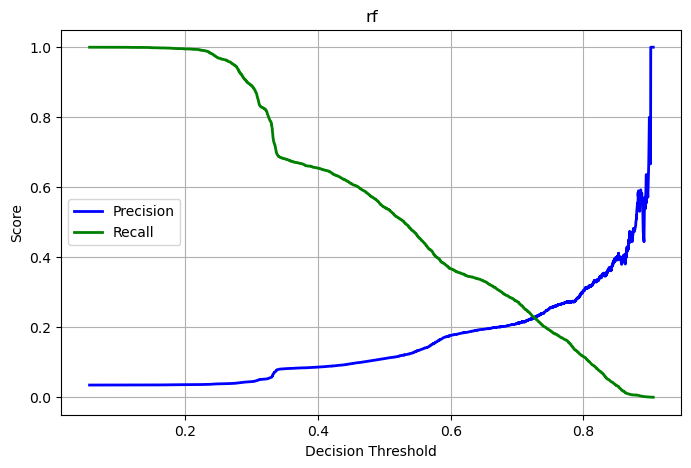

In [9]:
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, rf_proba)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision_vals[:-1], 'b-', linewidth=2, label='Precision')
plt.plot(thresholds, recall_vals[:-1],   'g-', linewidth=2, label='Recall')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('rf')
plt.legend()
plt.grid(True)
plt.show()

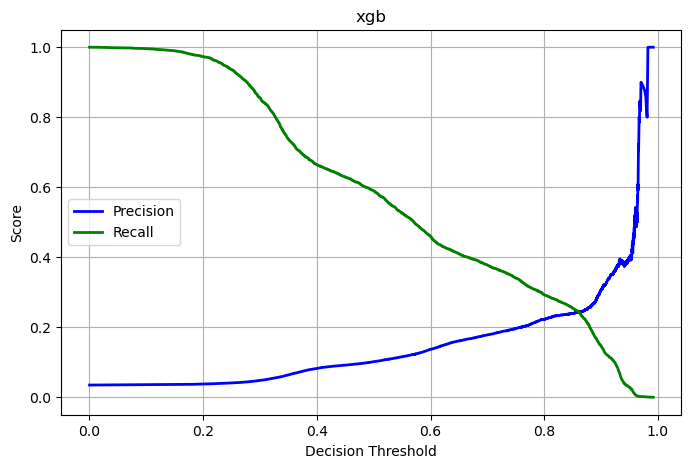

In [10]:
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, xgb_proba)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision_vals[:-1], 'b-', linewidth=2, label='Precision')
plt.plot(thresholds, recall_vals[:-1],   'g-', linewidth=2, label='Recall')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('xgb')
plt.legend()
plt.grid(True)
plt.show()

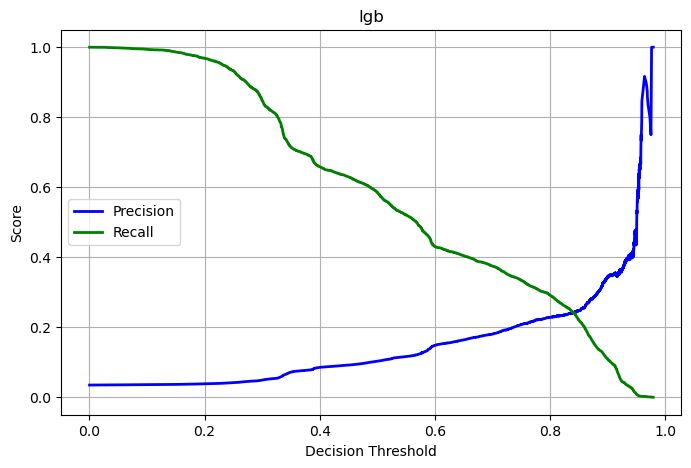

In [11]:
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, lgb_proba)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision_vals[:-1], 'b-', linewidth=2, label='Precision')
plt.plot(thresholds, recall_vals[:-1],   'g-', linewidth=2, label='Recall')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('lgb')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
#  finalized confidence threshold

rf_pred_spec  = (rf_proba  >= 0.82).astype(int)  # keep same ✅
xgb_pred_spec = (xgb_proba >= 0.68).astype(int)  # slight up from 0.65
lgb_pred_spec = (lgb_proba >= 0.58).astype(int)  # back up from 0.45

print("=== RF - High Precision ===")
print(classification_report(y_test_flat, rf_pred_spec))

print("=== XGB - Balanced ===")
print(classification_report(y_test_flat, xgb_pred_spec))

print("=== LGBM - High Recall ===")
print(classification_report(y_test_flat, lgb_pred_spec))


=== RF - High Precision ===
              precision    recall  f1-score   support

           0       0.97      0.99      0.98    113659
           1       0.33      0.08      0.13      4124

    accuracy                           0.96    117783
   macro avg       0.65      0.54      0.56    117783
weighted avg       0.95      0.96      0.95    117783

=== XGB - Balanced ===
              precision    recall  f1-score   support

           0       0.98      0.93      0.95    113659
           1       0.17      0.39      0.24      4124

    accuracy                           0.91    117783
   macro avg       0.57      0.66      0.60    117783
weighted avg       0.95      0.91      0.93    117783

=== LGBM - High Recall ===
              precision    recall  f1-score   support

           0       0.98      0.88      0.93    113659
           1       0.13      0.47      0.20      4124

    accuracy                           0.87    117783
   macro avg       0.55      0.68      0.57    117

In [13]:
# Majority voting — 2 out of 3 = fraud
votes = rf_pred_spec + xgb_pred_spec + lgb_pred_spec
majority_pred = (votes >= 2).astype(int)

# Full comparison table
comparison = pd.DataFrame({
    'actual'          : y_test_flat,
    'rf_precision'    : rf_pred_spec,
    'xgb_balanced'    : xgb_pred_spec,
    'lgbm_recall'     : lgb_pred_spec,
    'majority_vote'   : majority_pred,
    'votes'           : votes
})

print("=== MAJORITY VOTING - 2/3 Agreement ===")
print(classification_report(y_test_flat, majority_pred))

print("\n=== ACTUAL FRAUD TRANSACTIONS ===")
print(comparison[comparison['actual'] == 1].head(15).to_string())

print("\n=== ACTUAL NON-FRAUD TRANSACTIONS ===")
print(comparison[comparison['actual'] == 0].head(15).to_string())

=== MAJORITY VOTING - 2/3 Agreement ===
              precision    recall  f1-score   support

           0       0.98      0.93      0.95    113659
           1       0.17      0.39      0.24      4124

    accuracy                           0.91    117783
   macro avg       0.57      0.66      0.60    117783
weighted avg       0.95      0.91      0.93    117783


=== ACTUAL FRAUD TRANSACTIONS ===
     actual  rf_precision  xgb_balanced  lgbm_recall  majority_vote  votes
4         1             1             1            1              1      3
11        1             0             1            1              1      2
23        1             0             1            1              1      2
51        1             0             0            0              0      0
79        1             0             0            0              0      0
95        1             0             1            1              1      2
99        1             0             1            1              1      

In [14]:
thresholds = {
    'rf'  : 0.82,
    'xgb' : 0.68,
    'lgb': 0.58,
}
# joblib.dump(thresholds, 'confidence_thresholds.pkl')

In [15]:
rf_pred_spec  = (rf_proba  >= 0.5).astype(int)  # keep same ✅
xgb_pred_spec = (xgb_proba >= 0.5).astype(int)  # slight up from 0.65
lgb_pred_spec = (lgb_proba >= 0.5).astype(int)  # back up from 0.45

print("=== RF ===")
print(classification_report(y_test_flat, rf_pred_spec))

print("=== XGB ===")
print(classification_report(y_test_flat, xgb_pred_spec))

print("=== LGBM ===")
print(classification_report(y_test_flat, lgb_pred_spec))

=== RF ===
              precision    recall  f1-score   support

           0       0.98      0.84      0.91    113659
           1       0.11      0.54      0.18      4124

    accuracy                           0.83    117783
   macro avg       0.55      0.69      0.54    117783
weighted avg       0.95      0.83      0.88    117783

=== XGB ===
              precision    recall  f1-score   support

           0       0.98      0.81      0.89    113659
           1       0.10      0.59      0.17      4124

    accuracy                           0.80    117783
   macro avg       0.54      0.70      0.53    117783
weighted avg       0.95      0.80      0.86    117783

=== LGBM ===
              precision    recall  f1-score   support

           0       0.98      0.82      0.89    113659
           1       0.10      0.59      0.18      4124

    accuracy                           0.81    117783
   macro avg       0.54      0.70      0.53    117783
weighted avg       0.95      0.81     

In [16]:
x_test['is_identity_seen_before'].unique()

array(['nan', 'Found', 'New'], dtype=object)

In [17]:
x_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117783 entries, 0 to 117782
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   card_type                117783 non-null  object 
 1   purchaser_email_domain   117783 non-null  object 
 2   device_type              117783 non-null  object 
 3   is_identity_seen_before  117783 non-null  object 
 4   user_os                  117783 non-null  object 
 5   user_browser             117783 non-null  object 
 6   environment_risk         117783 non-null  object 
 7   card_info                117783 non-null  object 
 8   time_hour                117783 non-null  object 
 9   amt_bins                 117783 non-null  object 
 10  day_of_week              117783 non-null  object 
 11  time_diff_log            117783 non-null  float64
 12  amt_log                  117783 non-null  float64
 13  time_diff_bins           117783 non-null  object 
 14  card

In [18]:
x_test['card_type_user_os'].unique()

array(['debit_Windows', 'debit_missing', 'credit_missing', 'debit_Other',
       'missing_missing', 'credit_Windows', 'credit_Other', 'debit_iOS',
       'credit_macOS', 'credit_iOS', 'credit_Android', 'debit_macOS',
       'debit_Android', 'debit_Linux', 'missing_Other', 'credit_Linux',
       'debit or credit_missing', 'charge card_Other',
       'charge card_Windows', 'missing_Android'], dtype=object)

In [19]:
for i in x_test.columns:
    print(i)

card_type
purchaser_email_domain
device_type
is_identity_seen_before
user_os
user_browser
environment_risk
card_info
time_hour
amt_bins
day_of_week
time_diff_log
amt_log
time_diff_bins
card_type_user_os
card_network


In [21]:
test = pd.read_csv('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Data/test_final.csv')
for i in test.columns:
    print(i)

transaction_id
transaction_time
transaction_amount
card_network
card_type
purchaser_email_domain
device_type
is_identity_seen_before
user_os
user_browser


In [22]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506691 entries, 0 to 506690
Data columns (total 10 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_id           506691 non-null  int64  
 1   transaction_time         506691 non-null  int64  
 2   transaction_amount       506691 non-null  float64
 3   card_network             503605 non-null  object 
 4   card_type                503684 non-null  object 
 5   purchaser_email_domain   437499 non-null  object 
 6   device_type              136931 non-null  object 
 7   is_identity_seen_before  136977 non-null  object 
 8   user_os                  70659 non-null   object 
 9   user_browser             136625 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 38.7+ MB


In [24]:
x_test['card_info'].unique()

array(['visa_debit', 'mastercard_debit', 'visa_credit',
       'mastercard_credit', 'american express_credit', 'discover_credit',
       'discover_debit', 'american express_debit'], dtype=object)

In [26]:
pred = pd.read_csv('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Data/predictions.csv')
pred.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506691 entries, 0 to 506690
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_id           506691 non-null  int64  
 1   card_type                503684 non-null  object 
 2   purchaser_email_domain   437499 non-null  object 
 3   device_type              136931 non-null  object 
 4   is_identity_seen_before  136977 non-null  object 
 5   user_os                  506691 non-null  object 
 6   user_browser             506691 non-null  object 
 7   environment_risk         506691 non-null  int64  
 8   card_info                503600 non-null  object 
 9   time_hour                506691 non-null  int64  
 10  amt_bins                 506691 non-null  int64  
 11  day_of_week              506691 non-null  int64  
 12  time_diff_log            506691 non-null  float64
 13  amt_log                  506691 non-null  float64
 14  time

In [28]:
pred[['fraud_probability', 'fraud_prediction']]

,fraud_probability,fraud_prediction
0,0.382283,0
1,0.220001,0
2,0.416112,0
3,0.385043,0
4,0.374168,0
...,...,...
506686,0.373407,0
506687,0.391258,0
506688,0.419708,0
506689,0.353065,0
